# Training data preparation

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

weather = pd.read_csv('weatherAUS_rainfall_prediction_dataset_cleaned.csv')
solar = pd.read_csv("australia_solar_output_final.csv")
solar = solar.drop(columns=['ABS_Area_Name','Daily_PVOUT_kWh_kWp'])

# Preprocessing:
solar = solar.rename(columns={'City_Input': 'Location'}) #standardize column names for merging
weather['Date'] = pd.to_datetime(weather['Date'], format='mixed')
weather['Month'] = weather['Date'].dt.month
weather['Year'] = weather['Date'].dt.year
weather['RainToday'] = weather['RainToday'].map({'No': 0, 'Yes': 1}) # Convert 'Yes/No' to binary 
weather['RainTomorrow'] = weather['RainTomorrow'].map({'No': 0, 'Yes': 1})
# Feature Engineering:
weather['Cloud_Avg'] = (weather['Cloud9am'] + weather['Cloud3pm']) / 2
weather['Sun_Efficiency'] = weather['Sunshine'] / (weather['Cloud_Avg'] + 1)
# Filtering and merging:
weather_2016 = weather[weather['Year'] == 2016].copy()
data = pd.merge(weather_2016, solar[['Location', 'Month', 'Solar_Output_kWh_m2']], on=['Location', 'Month'])
# Get all numerical features:
features = ['Month', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 
            'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Cloud_Avg', 'Temp9am', 'Temp3pm', 
            'RainToday', 'RainTomorrow', 'Sun_Efficiency']
data = data.dropna(subset=features + ['Solar_Output_kWh_m2'])
X = data[features]
y = data['Solar_Output_kWh_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Data split (80% Train, 20% Test)

In [2]:
# FOR PROFILING
def get_data_profiling(df):
    profile_data = []
    for col in df.columns:
        profile_data.append({
            'Field': col,
            'Data Type': df[col].dtype,
            'No. of Records': len(df[col]),
            'No. of Unique Values': df[col].nunique(),
            'No. of Null/Missing Values': df[col].isnull().sum(),
            '% of Null/Missing Values': f"{(df[col].isnull().sum() / len(df)) * 100:.2f}%"})
    profile_df = pd.DataFrame(profile_data)
    numeric_summary = df.describe().T.reset_index().rename(columns={'index': 'Field'}) 
    return profile_df, numeric_summary
metadata_table, stat_table = get_data_profiling(data)
#stat_table
#metadata_table

# Model building with hypertuning

In [3]:
# Parameters to explore:
param_grid = {'n_estimators': [200, 300],        
    'max_depth': [20, 25, 30],          
    'max_features': [None],              
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True]}

# Grid search:
print("Training all model combinations...")
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='r2')
grid_search.fit(X_train, y_train)
print("\n" + "="*80)
print(f"{'PARAMETERS':<60} | {'AVG R² SCORE'}")
print("="*80)

# Extract results from the grid search object
results = grid_search.cv_results_

for mean_score, params in zip(results['mean_test_score'], results['params']):
    param_str = str(params)
    print(f"{param_str:<60} | {mean_score:.4f}")
print("="*80)

# Validation:
best_model = grid_search.best_estimator_
test_r2 = r2_score(y_test, best_model.predict(X_test))

print(f"\nWINNING PARAMETERS: {grid_search.best_params_}")
print(f"FINAL TEST SET R²:  {test_r2:.4f}")

joblib.dump(best_model, 'solar_predictor_model.pkl')
joblib.dump(features, 'model_features.pkl')

Training all model combinations...

PARAMETERS                                                   | AVG R² SCORE
{'bootstrap': True, 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 200} | 0.7807
{'bootstrap': True, 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 300} | 0.7812
{'bootstrap': True, 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 2, 'n_estimators': 200} | 0.7788
{'bootstrap': True, 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 2, 'n_estimators': 300} | 0.7793
{'bootstrap': True, 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 4, 'n_estimators': 200} | 0.7728
{'bootstrap': True, 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 4, 'n_estimators': 300} | 0.7731
{'bootstrap': True, 'max_depth': 25, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 200} | 0.7807
{'bootstrap': True, 'max_depth': 25, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 300} |

['model_features.pkl']

# Model evaluation

In [4]:
y_pred = best_model.predict(X_test)

print("-" * 40)
print("PERFORMANCE METRICS:")
print(f"R² Score (Accuracy):           {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error (MAE):     {mean_absolute_error(y_test, y_pred):.4f} kWh/m2")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} kWh/m2")
print("-"*40)

# Feature importance ranking
importances = pd.DataFrame({'Feature': features, 'Importance': 
                            best_model.feature_importances_}).sort_values(by='Importance', ascending=False)
importances

----------------------------------------
PERFORMANCE METRICS:
R² Score (Accuracy):           0.7834
Mean Absolute Error (MAE):     0.0504 kWh/m2
Root Mean Squared Error (RMSE): 0.0694 kWh/m2
----------------------------------------


,Feature,Importance
2,MaxTemp,0.309784
0,Month,0.299356
10,Humidity3pm,0.094274
17,Temp3pm,0.031791
1,MinTemp,0.030626
9,Humidity9am,0.028100
16,Temp9am,0.026912
11,Pressure9am,0.022357
4,Evaporation,0.022097
12,Pressure3pm,0.021285


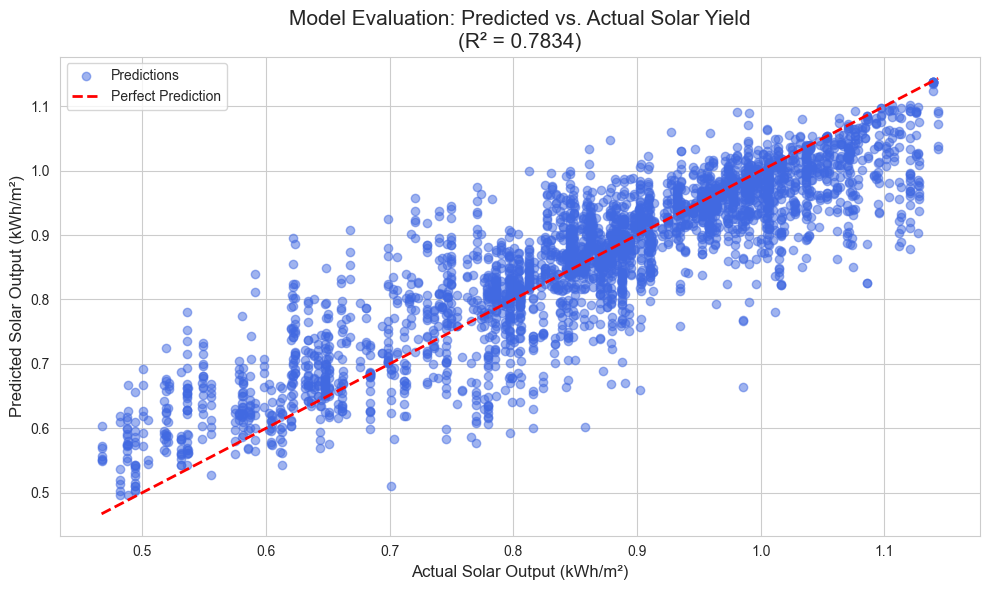

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_regression_results(y_test, y_pred):
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue', label='Predictions')
    line_coords = [y_test.min(), y_test.max()]
    plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
    plt.title(f'Model Evaluation: Predicted vs. Actual Solar Yield\n(R² = {r2_score(y_test, y_pred):.4f})', fontsize=15)
    plt.xlabel('Actual Solar Output (kWh/m²)', fontsize=12)
    plt.ylabel('Predicted Solar Output (kWh/m²)', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_regression_results(y_test, y_pred)

# NLP-based agent (simple version)

In [ ]:
import re
import pandas as pd
import joblib
from difflib import get_close_matches

class SolarAgent:
    def __init__(self, model_path, features_path, lookup_path, weather_path):
        self.model = joblib.load(model_path)
        self.model_features = joblib.load(features_path)
        self.lookup_df = pd.read_csv(lookup_path)  # look_up_table.csv
        self.weather_df = pd.read_csv(weather_path) # weatherAUS_cleaned
        self.weather_df['Date'] = pd.to_datetime(self.weather_df['Date'], format='mixed')
        self.history_2014 = self.weather_df[self.weather_df['Date'].dt.year == 2014].copy()
        # List of valid locations for typo checking
        self.valid_locations = self.lookup_df['Location'].unique().tolist()
        # Month mapping for text parsing
        self.month_map = {'january': 1, 'february': 2, 'march': 3, 'april': 4, 'may': 5, 'june': 6,
            'july': 7, 'august': 8, 'september': 9, 'october': 10, 'november': 11, 'december': 12,
            'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'jun': 6, 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}

    def _extract_location(self, text):
        words = text.title().split()
        for word in words:
            # check for exact or close matches (handles typos)
            match = get_close_matches(word, self.valid_locations, n=1, cutoff=0.7)
            if match:
                return match[0]
        return None

    def answer_question(self, question):
        q = question.lower()
        # Handle location typos 
        location = self._extract_location(question)
        if not location:
            return "Sorry, I can only provide solar output data for specific cities within Australia. Please check the spelling or try a major Australian city."
        # Extract month and weather details
        month = next((v for k, v in self.month_map.items() if k in q), None)
        # check for any weather info (ML will be triggered)
        weather_provided = any(feat.lower() in q for feat in self.model_features if feat != 'Month')
        # Handle scaling
        area_match = re.search(r'(\d+)\s*m2', q)
        area = float(area_match.group(1)) if area_match else 1.0

        # RULE 1a: Only location was given
        if not month and not weather_provided:
            avg_yield = self.lookup_df[self.lookup_df['Location'] == location]['Solar_Output_kWh_m2'].mean()
            return (f"A typical solar output in {location} is {avg_yield * area:.2f} kWh (for {area}m²). "
                    f"I can give you a more accurate answer if you provide the month.")

        # RULE 1b: Location and month was given (no weather)
        if month and not weather_provided:
            lookup_val = self.lookup_df[(self.lookup_df['Location'] == location) & 
                                        (self.lookup_df['Month'] == month)]['Solar_Output_kWh_m2'].values
            if len(lookup_val) > 0:
                return (f"A typical solar output in {location} for Month {month} is {lookup_val[0] * area:.2f} kWh (for {area}m²). "
                        f"I can give you a more accurate answer if you provide some weather information like temperature, humidity, pressure, or sunshine hours.")

        # RULE 2: Weather info provided (trigger to use the model)
        if weather_provided:
            # Fallback to month 5 if month not specified
            current_month = month if month else 5 
            
            # Get 2014 Baseline for this location/month
            baseline = self.history_2014[(self.history_2014['Location'] == location) & 
                                         (self.history_2014['Date'].dt.month == current_month)]
            
            # Ensure we have all model features
            weather_inputs = baseline[[f for f in self.model_features if f in baseline.columns]].mean().to_dict()
            
            # Overwrite with specific inputs from user
            for feature in self.model_features:
                pattern = rf"{feature.lower()}\s*(?:is|:)?\s*(\d+\.?\d*)"
                match = re.search(pattern, q)
                if match:
                    weather_inputs[feature] = float(match.group(1))
            # Re-calculate engineered features
            weather_inputs['Month'] = current_month
            weather_inputs['Cloud_Avg'] = (weather_inputs.get('Cloud9am', 4) + weather_inputs.get('Cloud3pm', 4)) / 2
            weather_inputs['Sun_Efficiency'] = weather_inputs.get('Sunshine', 8) / (weather_inputs['Cloud_Avg'] + 1)
            # predict
            input_df = pd.DataFrame([weather_inputs])[self.model_features]
            prediction = self.model.predict(input_df)[0]
            
            return (f"Based on the weather conditions provided, the predicted output for {location} is {prediction * area:.4f} kWh.\n"
                    f"(Model used inputs: Sunshine={weather_inputs.get('Sunshine', 'Avg')}, MaxTemp={weather_inputs.get('MaxTemp', 'Avg')})")

def run_interface():
    print("Initializing Solar Agent...")
    bot = SolarAgent('solar_predictor_model.pkl', 'model_features.pkl', 'look_up_table.csv', 'weatherAUS_rainfall_prediction_dataset_cleaned.csv')
    
    print("\nSolar Yield Agent Online.")
    while True:
        user_input = input("\nUser: ")
        if user_input.lower() in ['quit', 'exit']: break
        print(f"Agent: {bot.answer_question(user_input)}")

if __name__ == "__main__":
    run_interface()

# LLM Agent

In [12]:
import pandas as pd
import joblib
import json
import re
import ollama
import datetime
from difflib import get_close_matches

class SolarAgentPro:
    def __init__(self, model_path, lookup_path, features_path, weather_path):
        print("Initializing Agent Components...")
        self.ml_model = joblib.load(model_path)
        self.model_features = joblib.load(features_path)
        self.lookup_table = pd.read_csv(lookup_path)
        self.weather_df = pd.read_csv(weather_path)
        
        # Pre-process weather for baselines
        self.weather_df['Date'] = pd.to_datetime(self.weather_df['Date'], format='mixed')
        self.history_2014 = self.weather_df[self.weather_df['Date'].dt.year == 2014].copy()
        self.valid_cities = self.lookup_table['Location'].unique().tolist()
        print("Agent Online.")

    def handle_typos(self, city):
        """Fuzzy matching for city names."""
        matches = get_close_matches(str(city).capitalize(), self.valid_cities, n=1, cutoff=0.6)
        return matches[0] if matches else None

    def get_intent(self, user_query):
        """Robust JSON extraction with time-awareness."""
        now = datetime.datetime.now()
        current_month_val = now.month
        
        system_prompt = f"""
        Extract query details into JSON. 
        Context: Today is {now.strftime('%B %d, %Y')}.
        - location: City name string.
        - month: Integer 1-12 (If 'tomorrow', use {current_month_val}).
        - area: Numerical float (default 1.0).
        - weather: Dictionary of specifics (e.g., {{"Sunshine": 10}}). Empty {{}} if none.
        
        Output ONLY raw JSON.
        """
        
        try:
            response = ollama.chat(model='llama3', messages=[
                {'role': 'system', 'content': system_prompt},
                {'role': 'user', 'content': user_query}])
            
            content = response['message']['content']
            # Regex to isolate JSON block
            match = re.search(r'\{.*\}', content, re.DOTALL)
            if not match: return None
            
            data = json.loads(match.group())
            
            # Month Name to Integer Fallback
            if isinstance(data.get('month'), str):
                try:
                    data['month'] = datetime.datetime.strptime(data['month'], "%B").month
                except:
                    data['month'] = current_month_val
            
            return data
        except:
            return None

    def function_statistical_lookup(self, loc, month, area):
        """Logic for Basic Statistical Techniques (Look-Up Table)"""
        subset = self.lookup_table[(self.lookup_table['Location'] == loc) & 
                                   (self.lookup_table['Month'] == month)]
        if not subset.empty:
            return float(subset['Solar_Output_kWh_m2'].iloc[0]) * area
        return None

    def function_ml_prediction(self, loc, month, area, user_weather):
        """Logic for Machine Learning Model (Random Forest)"""
        # Get 2014 baseline for features the user didnt specify
        baseline = self.history_2014[(self.history_2014['Location'] == loc) & 
                                     (self.history_2014['Date'].dt.month == month)]
        
        # Safe Imputation: Fill missing features with 2014 means or zeros
        inputs = baseline[baseline.columns.intersection(self.model_features)].mean(numeric_only=True).fillna(0).to_dict()
        
        # Override with specific user weather
        inputs.update(user_weather)
        inputs['Month'] = month
        
        # Feature Engineering for the model
        c9 = float(inputs.get('Cloud9am', 4))
        c3 = float(inputs.get('Cloud3pm', 4))
        inputs['Cloud_Avg'] = (c9 + c3) / 2
        inputs['Sun_Efficiency'] = float(inputs.get('Sunshine', 5)) / (inputs['Cloud_Avg'] + 1)
        
        # Standardize for RF prediction
        input_row = []
        for feat in self.model_features:
            val = inputs.get(feat, 0)
            # Handle RainToday/RainTomorrow encoding
            if "Rain" in feat and isinstance(val, str):
                val = 1 if val.lower() == 'yes' else 0
            input_row.append(val)
            
        prediction = self.ml_model.predict([input_row])[0]
        return float(prediction) * area

    def solve(self, query):
        """Main dispatcher logic."""
        data = self.get_intent(query)
        if not data:
            return "I couldn't parse that request. Please include a city and a month (e.g., 'Sydney in June')."

        # 1. Location & Typo Check
        loc_raw = data.get('location', 'Sydney')
        loc = self.handle_typos(loc_raw)
        if not loc:
            return f"⚠️ Location '{loc_raw}' is outside my Australian dataset."

        # 2. Extract params
        month = data.get('month', 5)
        area = float(data.get('area', 1.0))
        weather = data.get('weather', {})

        # 3. Decision Gate: Statistics vs ML
        if isinstance(weather, dict) and len(weather) > 0:
            try:
                result = self.function_ml_prediction(loc, month, area, weather)
                source = "Machine Learning Model (Random Forest)"
            except Exception as e:
                return f"Model Error: {str(e)}"
        else:
            result = self.function_statistical_lookup(loc, month, area)
            source = "Statistical Look-Up Table"

        if result is None:
            return f"No data found for {loc} in Month {month}."

        month_name = datetime.datetime(1900, month, 1).strftime("%B")

        return (f"Your expected yield in {loc} in {month_name} for area {area}m² is {result:.2f} kWh\n"
                f"📊 Analysis Method: {source}")

# Running the interface:
import ipywidgets as widgets
from IPython.display import display

# Initialization
agent = SolarAgentPro(model_path='solar_predictor_model.pkl', 
    lookup_path='look_up_table.csv', 
    features_path='model_features.pkl',
    weather_path='weatherAUS_rainfall_prediction_dataset_cleaned.csv')

output_area = widgets.Output(layout={'border': '1px solid #444', 'padding': '10px', 'height': 'px'})
query_input = widgets.Text(placeholder='e.g., Yield in Perth for July with 12h sunshine?', layout={'width': '80%'})
submit_btn = widgets.Button(description='Ask Agent', button_style='success')

def on_action(b):
    with output_area:
        query = query_input.value
        if not query: return
        print(f"👤: {query}")
        print(f"🤖: {agent.solve(query)}")
        print("-" * 40)
        query_input.value = ""

submit_btn.on_click(on_action)
query_input.on_submit(on_action)

display(widgets.VBox([output_area, widgets.HBox([query_input, submit_btn])]))

Initializing Agent Components...
Agent Online.


/var/folders/xl/862grcc150nbw7496s56s6lw0000gp/T/ipykernel_56342/3875002714.py:166: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  query_input.on_submit(on_action)
